In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

#### Gradient Descent
- To better appreciate gradient descent, let me industrate it with model
- `Gradient descent` let model select best parameters for a given data
- `Gradient descent` is an iterative technique
commonly used in Machine Learning and Deep Learning to try to
find the best possible set of parameters / coefficients for a given
model, data points and loss function, starting from an initial, and
usually random, guess."


#### Data Generation
-  we will start with a very simple model
- `y = wx + b + e` where x: is feature vector, w is weight, b is bias and e is the error
- we will start with b=1, w=2


In [6]:
true_b = 1
true_w = 2
N= 100
np.random.seed(42)
x = np.random.rand(N, 1)
epsilon = (.1 * np.random.randn(N, 1))

y = true_w * x + true_b + epsilon

In [25]:
#-- shuffle the data

#shuffle the index
idx = np.arange(N)
np.random.shuffle(idx)


In [26]:
##train index
train_idx = idx[:int(0.8*N)]

#test index
test_idx = idx[int(0.8*N): ]

x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

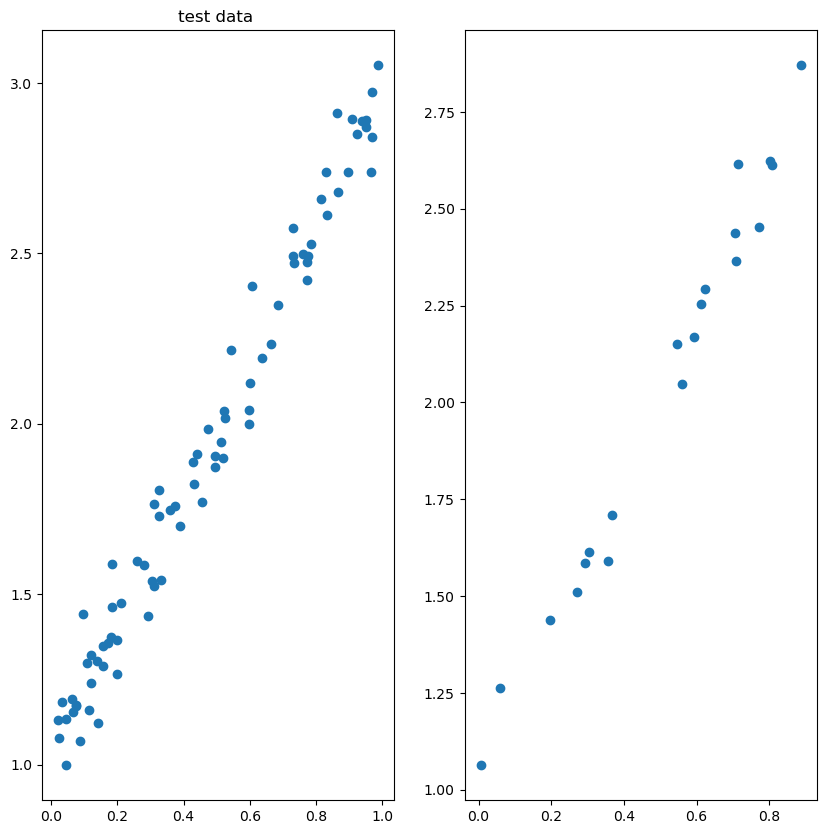

In [35]:
def plot_prediction(x_train, y_train, x_test=None, y_test=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))
    ax1.scatter(x_train, y_train)
    ax1.set_title("train data ")
    if x_test is not None:
        ax2.scatter(x_test, y_test)
        ax1.set_title("test data ")
    plt.show()
    
plot_prediction(x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)

#### Gradient Descent
- in this case we knew the values of w and b, it is not the case for real data
- if not so then why would we even train a model ?
- we are going to use Gradient Descent to get very close to or to these values !


 #### 1. Step Zero
- Initialiaze random values for parameters and biases

In [32]:
np.random.seed(42)
w = np.random.randn(1)
b = np.random.randn(1)
print(w, b)

[0.49671415] [-0.1382643]


#### Step 1 - Compute Model’s Predictions
- This is the `forward pass` - it simply computes the model’s predictions using the current values of the parameters/weights. At the very beginning, we will be producing reallybad predictions, as we started with random values from Step 0

In [37]:
y_hat = w * x_train + b
y_hat


array([[-0.06897573],
       [-0.04794927],
       [ 0.12006085],
       [ 0.00639333],
       [ 0.19081989],
       [ 0.29045139],
       [ 0.34334211],
       [ 0.31340801],
       [-0.03908351],
       [-0.05356256],
       [ 0.15909784],
       [ 0.22384388],
       [ 0.04777508],
       [-0.09430882],
       [-0.10669397],
       [ 0.22532745],
       [ 0.00127985],
       [-0.12563826],
       [-0.07764618],
       [ 0.33396895],
       [-0.04644448],
       [ 0.33306057],
       [-0.10595225],
       [ 0.29197765],
       [ 0.09629154],
       [-0.12118304],
       [-0.0846731 ],
       [-0.06077962],
       [-0.08974918],
       [ 0.12138449],
       [ 0.08036567],
       [ 0.25174371],
       [-0.07886015],
       [ 0.13130052],
       [ 0.30620911],
       [ 0.12238965],
       [-0.12803969],
       [ 0.10701096],
       [ 0.35193641],
       [ 0.0397907 ],
       [ 0.31964368],
       [ 0.27338135],
       [ 0.17841952],
       [-0.03955941],
       [ 0.10769708],
       [-0

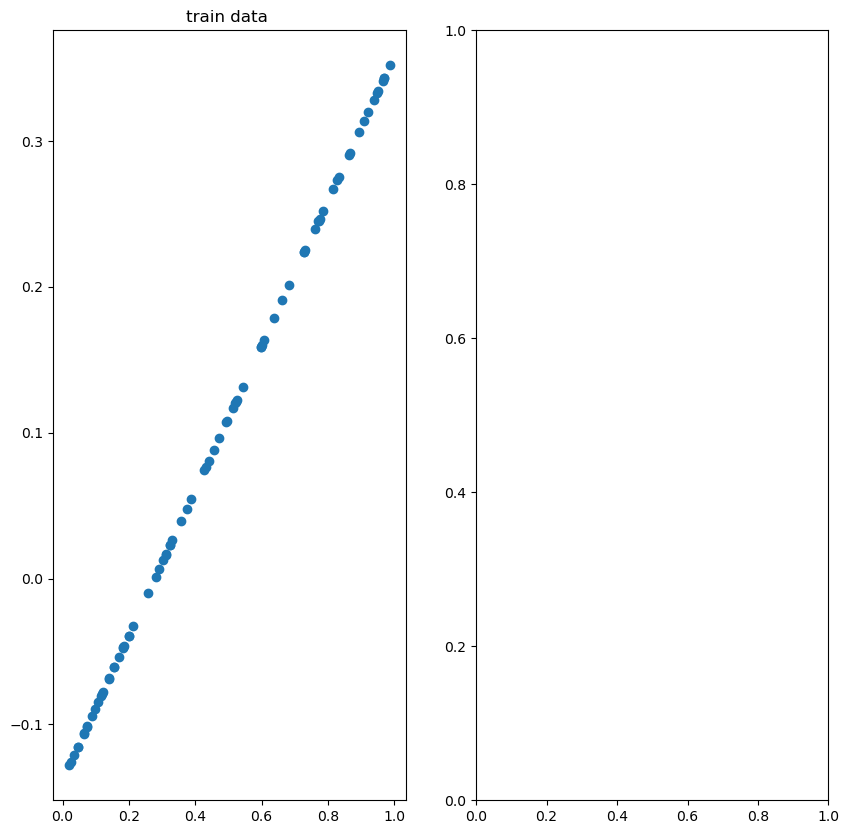

In [38]:
plot_prediction(x_train=x_train, y_train=y_hat)